In [48]:
!pip install mne numpy scipy scikit-learn matplotlib


In [49]:
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [50]:
!pip install mne

In [51]:
%pip install mne

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import mne

file_path = "BCICIV_2a_gdf/A01T.gdf"

raw = mne.io.read_raw_gdf(file_path, preload=True)

print(raw.info)


Extracting GDF parameters from BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


c:\Users\pravs\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>


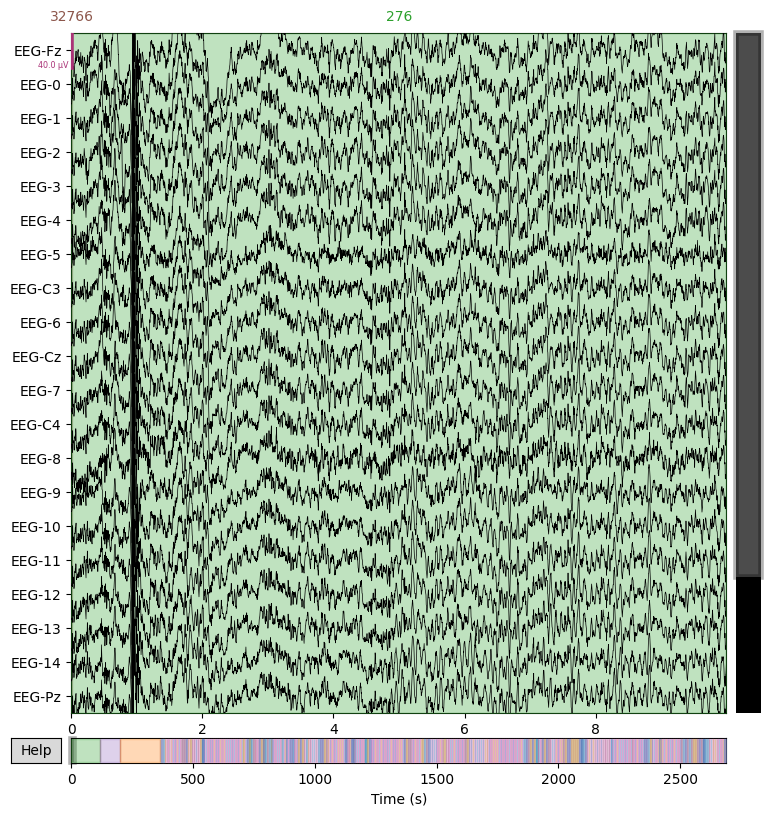

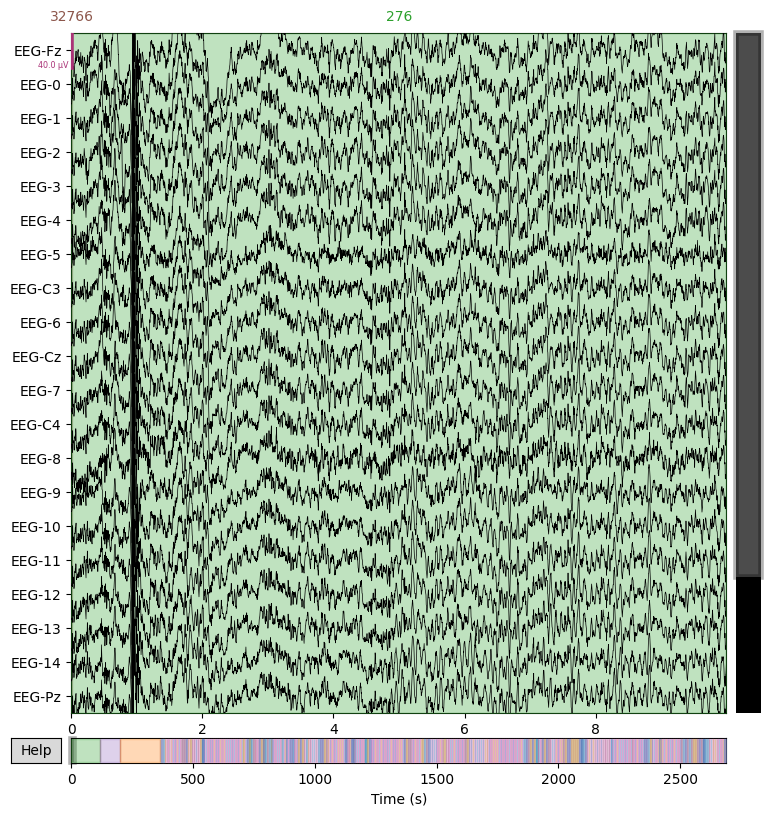

In [53]:
raw.plot()

In [54]:
raw.filter(8,30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

In [55]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


In [56]:
epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin=3,
    tmax=6,
    baseline=None,
    preload=True,
    event_repeated='drop'
)

print(epochs)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 585 events and 751 original time points ...
1 bad epochs dropped
<Epochs | 584 events (all good), 3 – 6 s (baseline off), ~83.7 MiB, data loaded,
 np.str_('32766'): 9
 np.str_('768'): 288
 np.str_('769'): 71
 np.str_('770'): 72
 np.str_('771'): 72
 np.str_('772'): 72>


In [57]:
X_train = epochs.get_data()
y_train = epochs.events[:, -1]

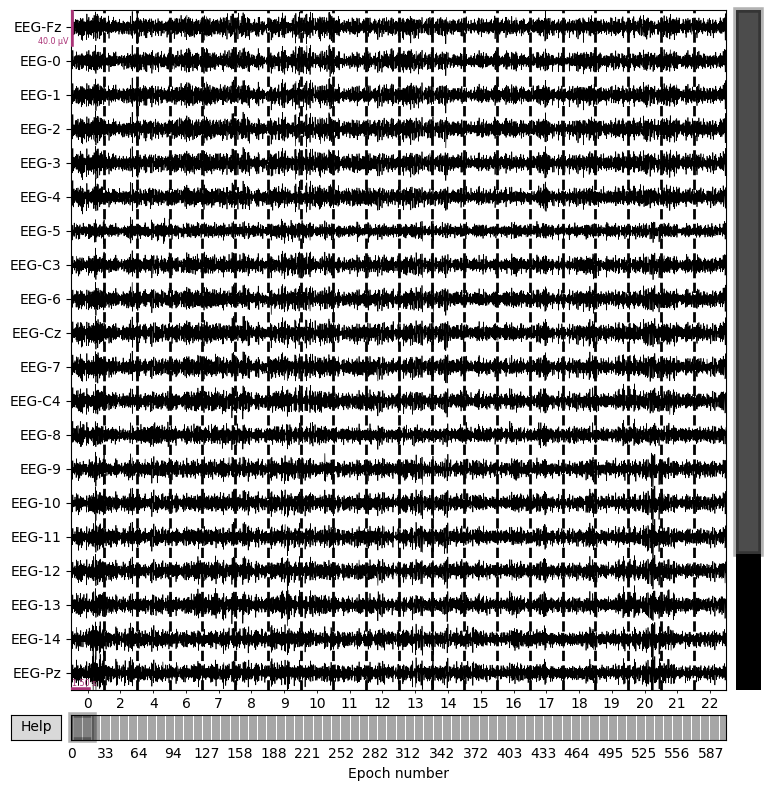

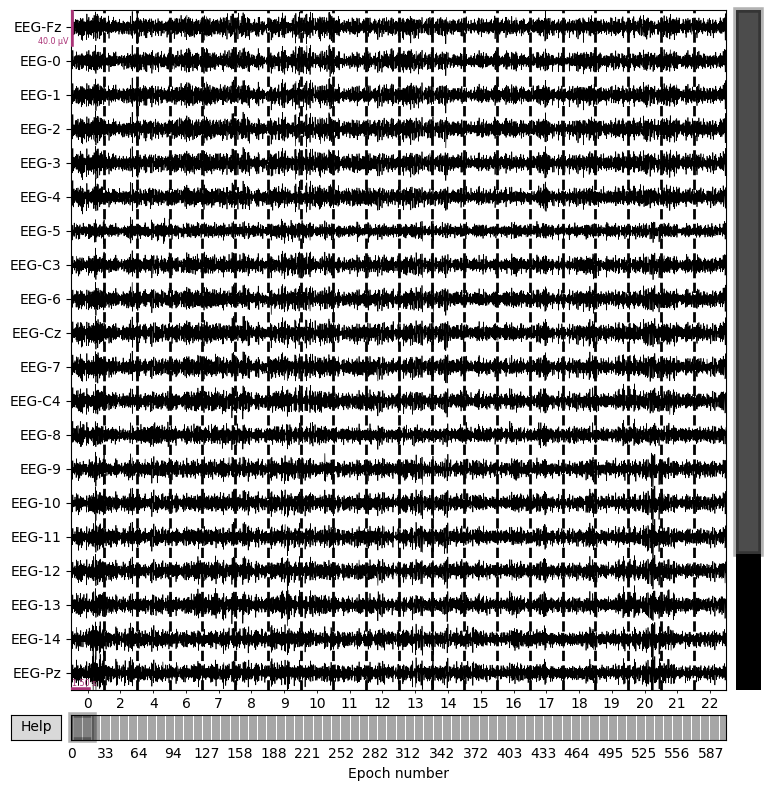

In [58]:
epochs.plot()

In [59]:
mask = np.logical_or(y_train == 7, y_train == 8)

X_train = X_train[mask]
y_train = y_train[mask]

In [60]:
csp = CSP(n_components=6, log=True)

X_train_csp = csp.fit_transform(X_train, y_train)

Computing rank from data with rank=None
    Using tolerance 0.00032 (2.2e-16 eps * 25 dim * 5.7e+10  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.


In [71]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

clf = SVC()

scores = cross_val_score(clf, X_train_csp, y_train, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.7472906403940887


In [72]:
X.shape
np.unique(y)

array([7, 8])

In [73]:
raw_eval = mne.io.read_raw_gdf("BCICIV_2a_gdf/A01E.gdf", preload=True)

raw_eval.filter(8,30)

Extracting GDF parameters from BCICIV_2a_gdf/A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


c:\Users\pravs\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~131.1 MiB, data loaded>

In [74]:
events_eval, event_id_eval = mne.events_from_annotations(raw_eval)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('783')]


In [75]:
epochs_eval = mne.Epochs(
    raw_eval,
    events_eval,
    event_id_eval,
    tmin=3,
    tmax=6,
    baseline=None,
    preload=True,
    event_repeated='drop'
)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 585 events and 751 original time points ...
1 bad epochs dropped


In [76]:
X_eval = epochs_eval.get_data()
y_eval = epochs_eval.events[:, -1]

In [77]:
mask = np.logical_or(y_eval == 7, y_eval == 8)

X_eval = X_eval[mask]
y_eval = y_eval[mask]

In [78]:
mask = np.logical_or(y_eval == 7, y_eval == 8)

X_eval = X_eval[mask]
y_eval = y_eval[mask]

In [79]:
X_eval_csp = csp.transform(X_eval)

In [80]:
y_pred = model.predict(X_eval_csp)

accuracy = accuracy_score(y_eval, y_pred)

print("Evaluation Accuracy:", accuracy)

Evaluation Accuracy: 0.4634146341463415
